# 03 Exploratory Data Analysis

This notebook explores the cleaned Swiggy dataset through distribution analysis, categorical analysis, time-based trends, and correlation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

current_dir = Path.cwd().resolve()
PROJECT_ROOT = current_dir.parent if current_dir.name.strip() == 'notebooks' else current_dir
FIGURES_PATH = PROJECT_ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
FIG_SIZE = (12, 5)

In [2]:
PROCESSED_PATH = PROJECT_ROOT / 'data/processed/swiggy_cleaned.csv'
df = pd.read_csv(PROCESSED_PATH, parse_dates=['order_date'])
df_clean_price = df[df['is_price_outlier'] == False]
print('Loaded:', df.shape)
df.head()

Loaded: (91788, 14)


,state,city,order_date,restaurant_name,location,category,dish_name,price_inr,rating,rating_count,is_price_outlier,month,day_of_week,price_bucket
0,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,False,2025-04,Thursday,Budget
1,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,False,2025-01,Wednesday,Budget
2,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34,False,2025-01,Tuesday,Budget
3,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29,False,2025-05,Friday,Mid-range
4,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51,False,2025-07,Wednesday,Mid-range


## 1. Distribution Analysis

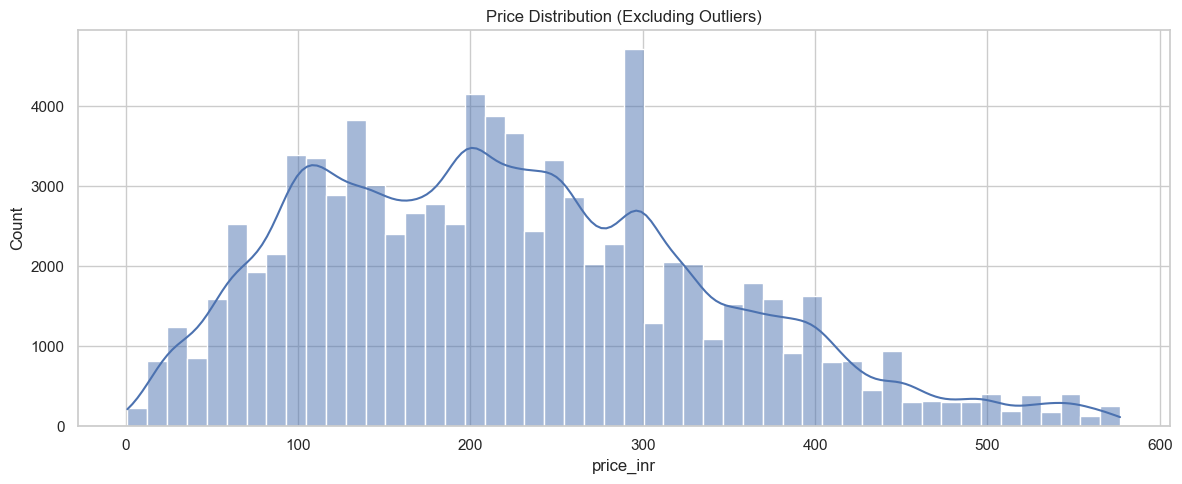

In [3]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.histplot(df_clean_price['price_inr'], bins=50, kde=True, ax=ax)
ax.set_title('Price Distribution (Excluding Outliers)')
ax.set_xlabel('price_inr')
ax.set_ylabel('Count')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '01_price_distribution.png', dpi=150)
plt.show()

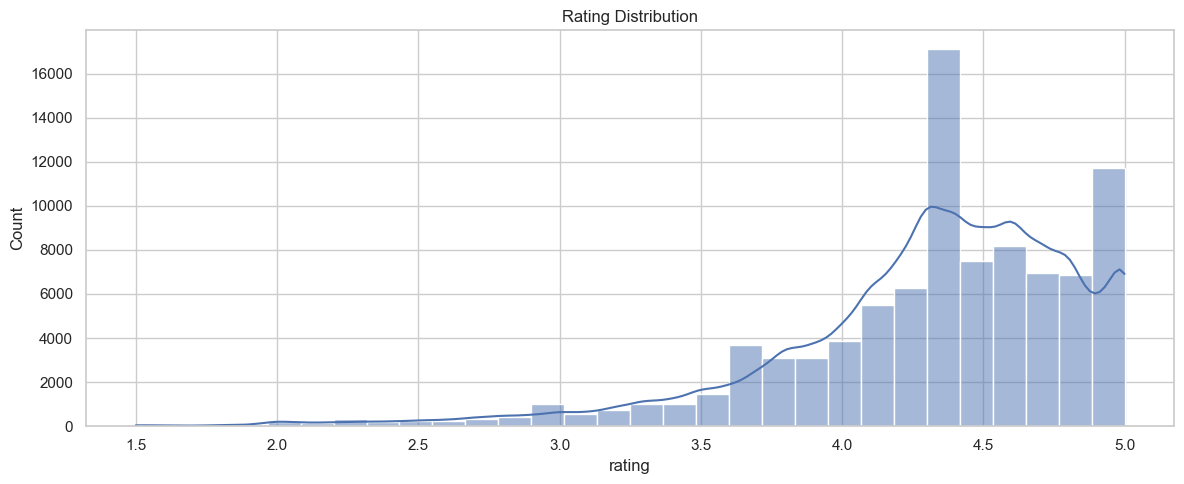

In [4]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.histplot(df['rating'], bins=30, kde=True, ax=ax)
ax.set_title('Rating Distribution')
ax.set_xlabel('rating')
ax.set_ylabel('Count')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '02_rating_distribution.png', dpi=150)
plt.show()

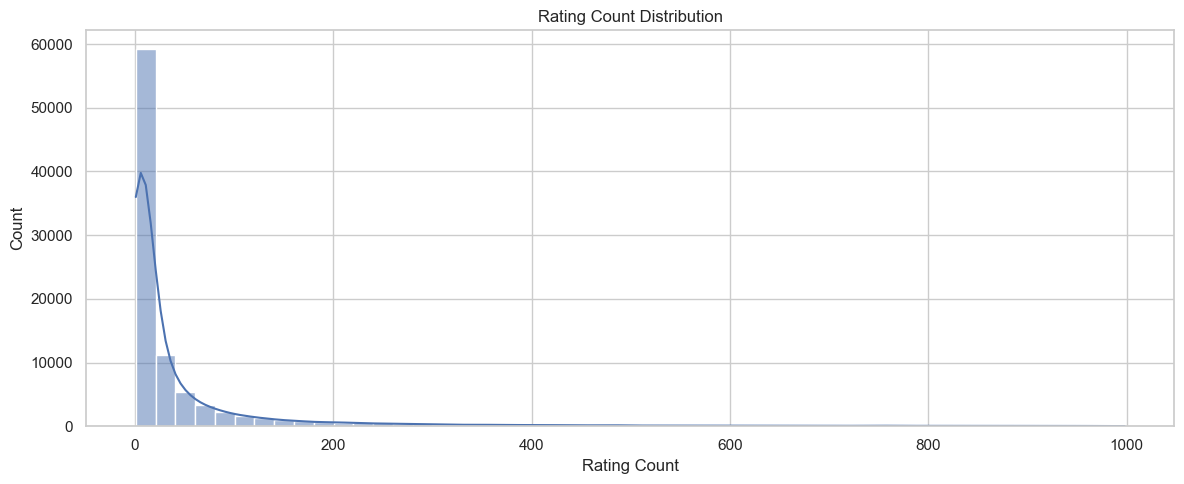

In [5]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.histplot(df['rating_count'], bins=50, kde=True, ax=ax)
ax.set_title('Rating Count Distribution')
ax.set_xlabel('Rating Count')
ax.set_ylabel('Count')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '03_rating_count_distribution.png', dpi=150)
plt.show()

## 2. Categorical Analysis

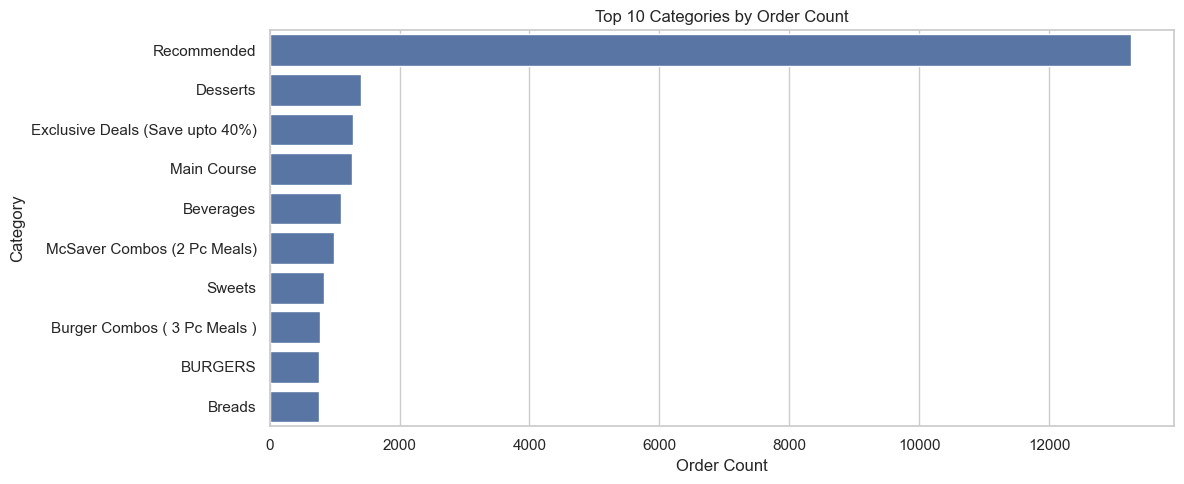

In [6]:
top_categories = df['category'].value_counts().head(10)
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax)
ax.set_title('Top 10 Categories by Order Count')
ax.set_xlabel('Order Count')
ax.set_ylabel('Category')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '04_top10_categories.png', dpi=150)
plt.show()

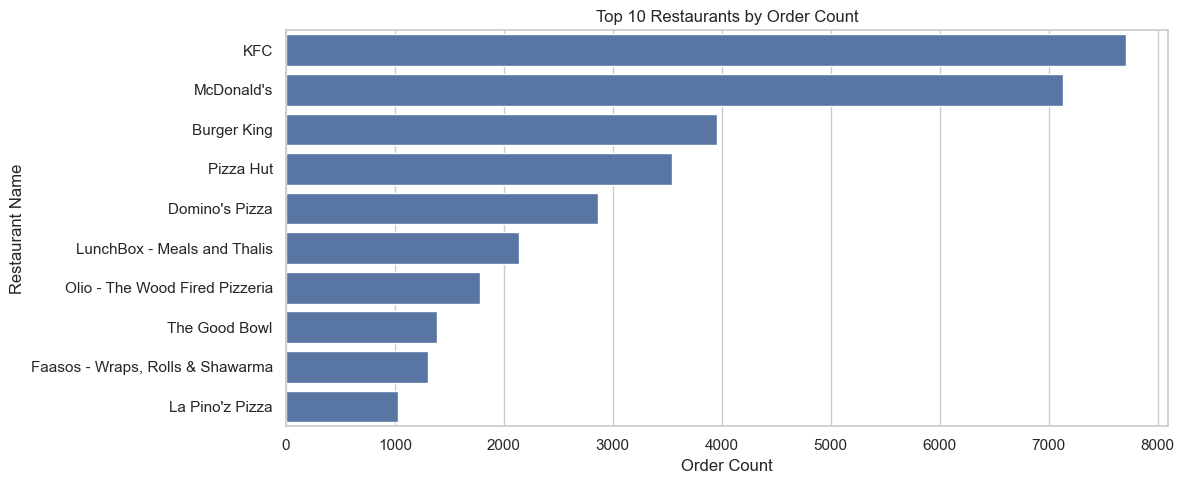

In [7]:
top_restaurants = df['restaurant_name'].value_counts().head(10)
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(x=top_restaurants.values, y=top_restaurants.index, ax=ax)
ax.set_title('Top 10 Restaurants by Order Count')
ax.set_xlabel('Order Count')
ax.set_ylabel('Restaurant Name')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '05_top10_restaurants.png', dpi=150)
plt.show()

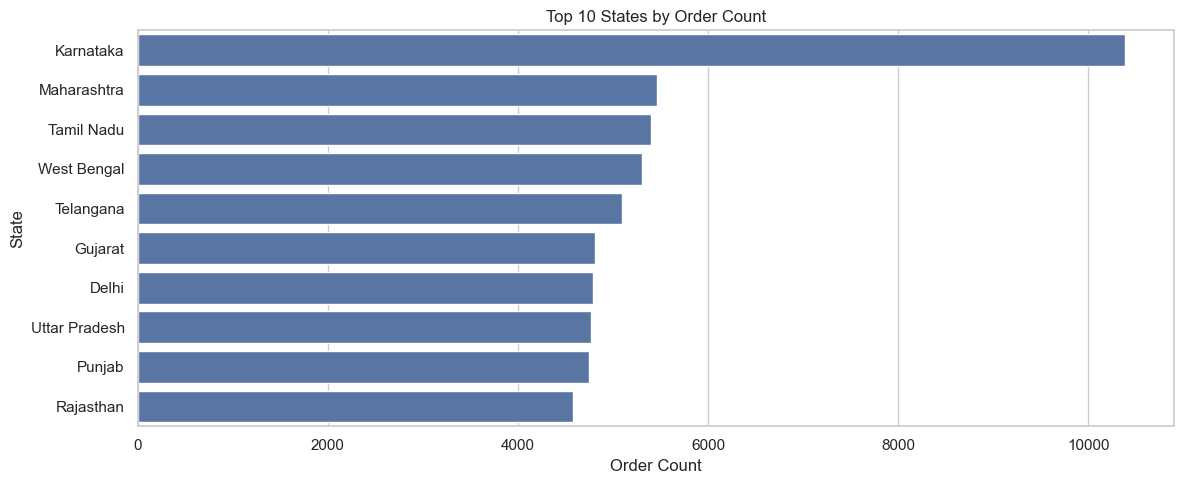

In [8]:
orders_by_state = df['state'].value_counts().head(10)
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(x=orders_by_state.values, y=orders_by_state.index, ax=ax)
ax.set_title('Top 10 States by Order Count')
ax.set_xlabel('Order Count')
ax.set_ylabel('State')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '06_orders_by_state.png', dpi=150)
plt.show()

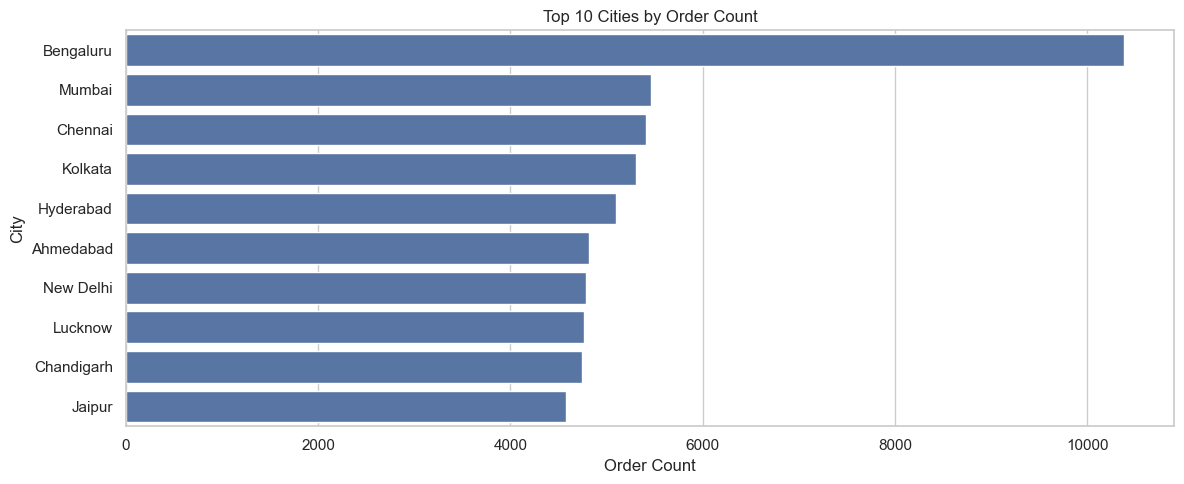

In [9]:
orders_by_city = df['city'].value_counts().head(10)
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(x=orders_by_city.values, y=orders_by_city.index, ax=ax)
ax.set_title('Top 10 Cities by Order Count')
ax.set_xlabel('Order Count')
ax.set_ylabel('City')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '07_orders_by_city.png', dpi=150)
plt.show()

## 3. Time Analysis

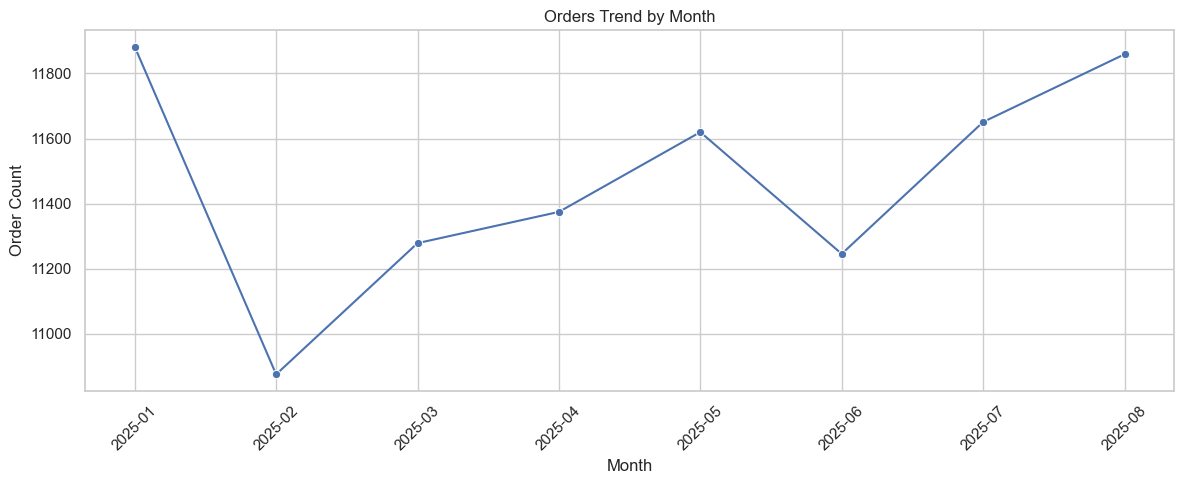

In [10]:
df['month'] = df['order_date'].dt.to_period('M').astype(str)
orders_by_month = df.groupby('month').size().reset_index(name='Order Count')
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.lineplot(data=orders_by_month, x='month', y='Order Count', marker='o', ax=ax)
ax.set_title('Orders Trend by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_PATH / '08_orders_by_month.png', dpi=150)
plt.show()

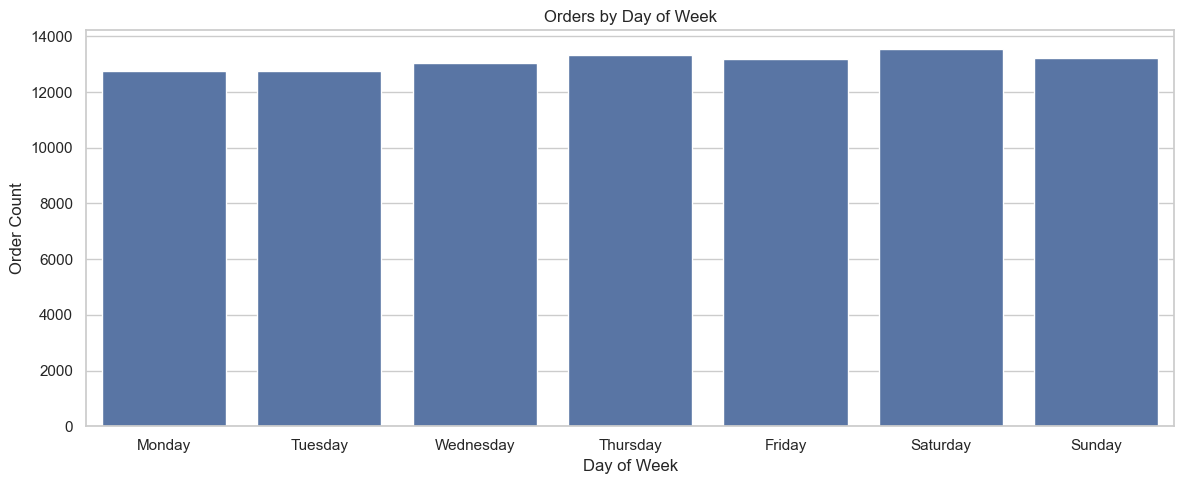

In [11]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['order_date'].dt.day_name(), categories=day_order, ordered=True)
orders_by_day = df.groupby('day_of_week', observed=True).size().reset_index(name='Order Count')
fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(data=orders_by_day, x='day_of_week', y='Order Count', ax=ax)
ax.set_title('Orders by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Order Count')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '09_orders_by_dayofweek.png', dpi=150)
plt.show()

## 4. Correlation Heatmap

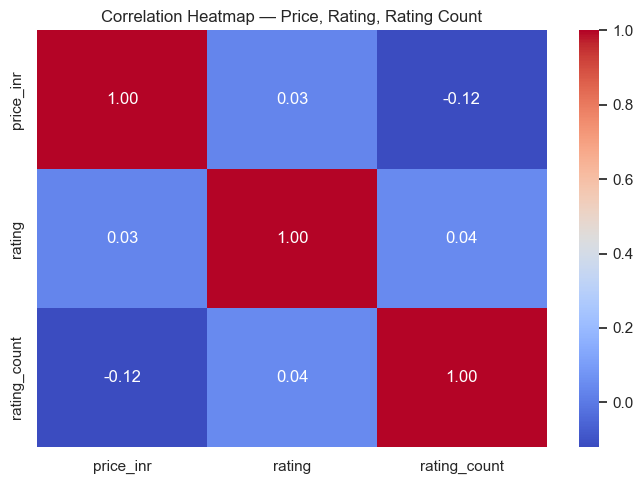

In [12]:
corr_cols = ['price_inr', 'rating', 'rating_count']
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap — Price, Rating, Rating Count')
plt.tight_layout()
fig.savefig(FIGURES_PATH / '10_correlation_heatmap.png', dpi=150)
plt.show()